In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

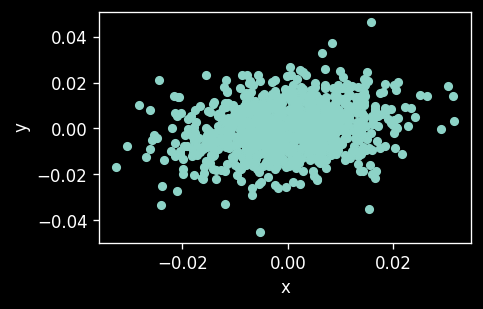

In [7]:
# 1 - CREATE DATA
# the idea is to create a dataframe with variables started with x and target returns started with y
# columns then can be x1, x_1, x2, xsomething ... and y1, y, y2, y_3
# index should be a datetime 
# this is the part where we spend most time researching :)
# lets generate some synthetic data 
n = 1000
x = np.random.normal(0, 0.01, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.01,n)
df = pd.DataFrame()
df['x'] = x
df['y'] = y
df.index = pd.date_range('2000-01-01', freq = 'D', periods = n)
df.plot.scatter('x', 'y')
plt.show()


In [8]:
# 2 - CREATE TM OBJECTS
# since we are dealing with a single dataset lets keep this simple 
# you can inspect the package code to get a better idea
# but this should be enough to get you started with some real examples
tm_data = tm.Data.from_df(df)

# now we define the model
# a model is a sequential application of transformations to data, a base model and how that
#   model is used to allocate capital
# most likely you want to focus on the base model and some simple transforms (that we ignore now)
#   as allocation must be a "solved" problem

# tm.base contains the models! you can check the abstract class BaseModel and how the 
#   others are build to create you own probabilist structures (aka models)
# lets use a linear regression with optimal allocation (why use another anyway..)
base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model = tm.Model(base_model = base_model, allocation = alloc)
model.estimate(tm_data)
model.view()



* Model *
** Linear Regression **
Weights:  [1.46833970e-04 2.29601536e-01]
Variance:  0.00010267342195189699


Weight norm:  1.0
Weight mean:  [0.]




100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 102.42it/s]


Post process for key data


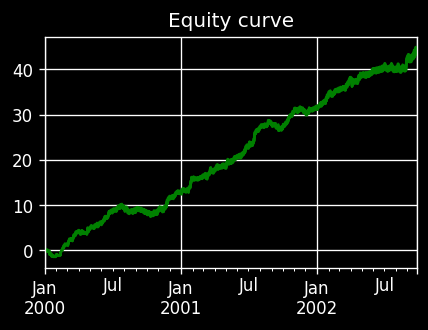

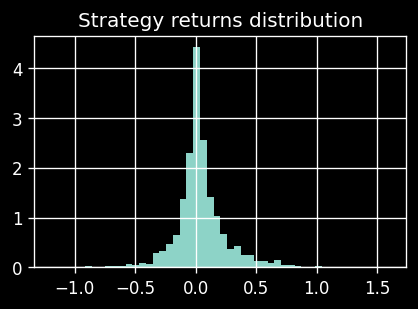

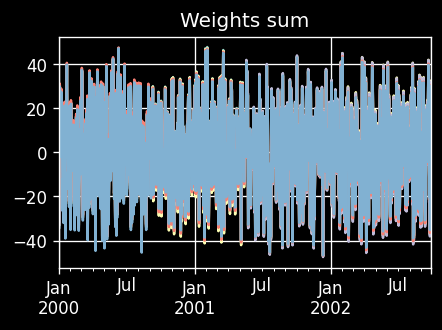

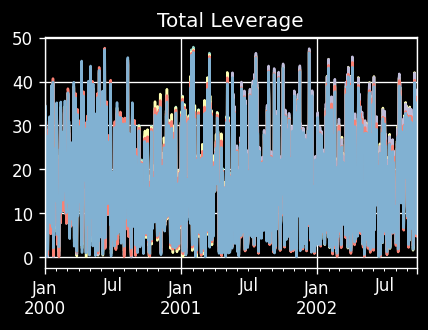

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


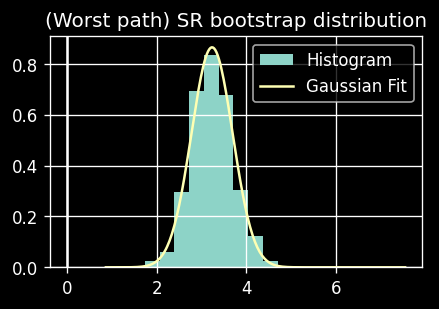


** PERFORMANCE SUMMARY **

Return:  10.971130987608204
Standard deviation:  3.4391383603023034
Sharpe:  3.1900813047381527



,path_1,path_2,path_3,path_4,path_5
2000-01-01,-0.013787,-0.008020,-0.013971,-0.016638,-0.001727
2000-01-02,0.243145,0.254395,0.245371,0.250224,0.263452
2000-01-03,-0.145784,-0.146571,-0.147168,-0.152359,-0.145998
2000-01-04,0.078780,0.079164,0.079526,0.082379,0.078816
2000-01-05,-0.347347,-0.348078,-0.350602,-0.364173,-0.345597
...,...,...,...,...,...
2002-09-22,0.077518,0.079732,0.083926,0.079172,0.074699
2002-09-23,0.437668,0.461944,0.456471,0.432352,0.428341
2002-09-24,-0.199333,-0.205065,-0.210034,-0.201057,-0.193986
2002-09-25,-0.008432,-0.009810,-0.008244,-0.007584,-0.008482


In [9]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = tm_data, 
        modelset = model,            
        n_paths = 5,
        k_folds = 4, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )
paths.post_process(pct_fee = 0)

In [12]:
x = np.random.normal(0,1,(10,3))
q = np.quantile(np.abs(x), 0.8, axis = 0, method = 'closest_observation')
# now, if abs(x) along axis 0 is larger than the respective quantile we clip it

x

array([[-0.88554553, -0.05273063,  0.15570736],
       [ 0.80021037, -0.08468413,  0.89899749],
       [ 0.21380707,  1.78642722, -1.74149715],
       [ 1.151566  , -0.55396171,  0.11268122],
       [-1.26386916, -1.8483013 ,  1.35839857],
       [ 0.4280127 , -0.39234314, -0.00621599],
       [-0.08948339,  2.15770233, -1.58843627],
       [-0.56788829,  0.66354042,  0.80854862],
       [ 0.51586498,  0.76596908, -0.68472636],
       [-0.80880315, -0.49348343,  1.21229711]])

In [14]:
q = np.quantile(np.abs(x), 0.8, axis = 0, method = 'closest_observation')
q

array([0.88554553, 1.78642722, 1.35839857])

In [16]:
np.clip(x, -q, q)


array([[-0.88554553, -0.05273063,  0.15570736],
       [ 0.80021037, -0.08468413,  0.89899749],
       [ 0.21380707,  1.78642722, -1.35839857],
       [ 0.88554553, -0.55396171,  0.11268122],
       [-0.88554553, -1.78642722,  1.35839857],
       [ 0.4280127 , -0.39234314, -0.00621599],
       [-0.08948339,  1.78642722, -1.35839857],
       [-0.56788829,  0.66354042,  0.80854862],
       [ 0.51586498,  0.76596908, -0.68472636],
       [-0.80880315, -0.49348343,  1.21229711]])